In [1]:
import os, time
import chipwhisperer as cw

BITFILE = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

assert os.path.isfile(BITFILE), f"Bitstream not found: {BITFILE}"

# 1) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()


# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", BITFILE)
target = cw.target(scope, cw.targets.CW305, bsfile=BITFILE, force=True)


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 3229802                   to 16535027                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 9816387                   to 29538471                 
scope.clock.adc_rate                     changed from 9816387.0                 to 29538471.0               
scope.clock.freq_ct

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\sbista\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", EXP_CT.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == EXP_CT)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


In [6]:
scope.default_setup()
scope.adc.samples = 500         # number of samples per trace
scope.adc.offset  = 0
scope.adc.presamples = 200       # capture a bit before trigger
scope.adc.decimate = 1
scope.adc.timeout = 2
# ---- Gain (CWLite safe range: 20–45 dB) ----
scope.gain.db = 35
# ---- Trigger: FPGA asserts trigger at AES start ----
scope.trigger.triggers = "tio4"
#scope.trigger.module = "basic"

print(scope)

scope.clock.adc_freq                     changed from 29538471                  to 7384609                  
scope.clock.adc_rate                     changed from 29538471.0                to 7384609.0                
scope.clock.adc_locked                   changed from True                      to False                    
cwlite Device
sn         = 50203220594a48303130313230313035
fw_version = 
    major = 0
    minor = 65
    debug = 0
gain = 
    mode = high
    gain = 46
    db   = 35.1484375
adc = 
    state          = False
    basic_mode     = rising_edge
    timeout        = 2
    offset         = 0
    presamples     = 200
    samples        = 500
    decimate       = 1
    trig_count     = 16535607
    fifo_fill_mode = normal
clock = 
    adc_src       = clkgen_x4
    adc_phase     = 0
    adc_freq      = 7384609
    adc_rate      = 7384609.0
    adc_locked    = False
    freq_ctr      = 0
    freq_ctr_src  = extclk
    clkgen_src    = system
    extclk_freq   = 10000000
  

In [7]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


In [8]:
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


Trace length: 500


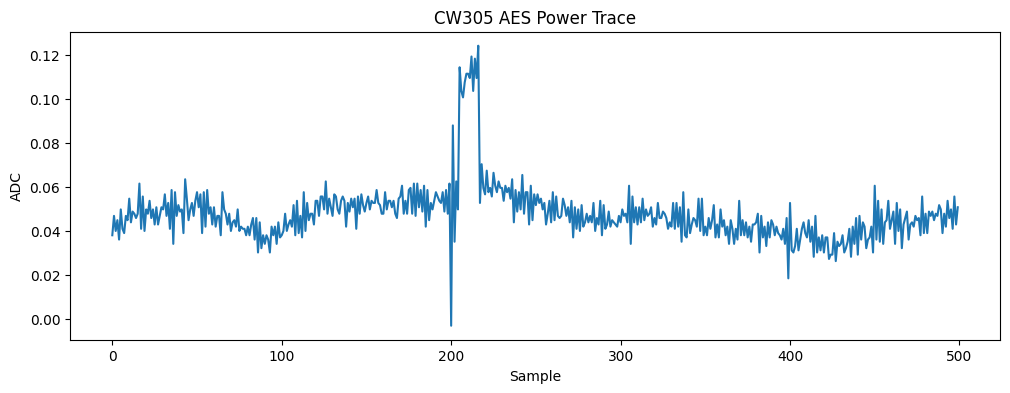

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [10]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


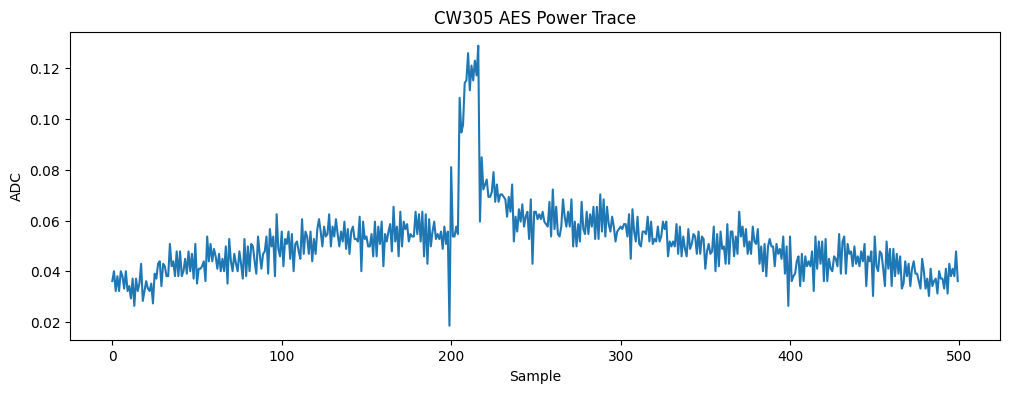

In [11]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [12]:
import chipwhisperer as cw
import numpy as np
import time

# Use your existing scope/target if already connected
# scope = cw.scope()
# target = cw.target(scope, cw.targets.CW305)

# fixed vectors (good for glitch scanning)
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")

KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

target.fpga_write(target.REG_CRYPT_KEY, KEY)

# expected ciphertext
from Crypto.Cipher import AES
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected:", EXP_CT.hex())


Expected: 06f36a65e8a99ff8907b2e5e5ddd77de


In [12]:
scope.gain.gain = 40
scope.gain.mode = "high"
scope.adc.samples = 350
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 175
scope.trigger.triggers = "tio4"

In [13]:
scope.clock.extclk_freq = 10000000
scope.clock.clkgen_mul = 5
scope.clock.clkgen_div = 48
scope.clock.clkgen_freq = 10000000

In [14]:
scope.io.glitch_lp = True
scope.io.glitch_hp = True

In [15]:
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0

In [16]:
scope.glitch.trigger_src ="ext_single" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor"

In [17]:
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5   
print("Glitch ready.")

Glitch ready.


In [14]:
# --- Capture settings ---
#scope.default_setup()
# scope.gain.db = 35
# scope.adc.samples = 3000
# scope.adc.presamples = 200
# scope.adc.timeout = 2





# --- Clocking (typical CWLite setup) ---
# Keep these consistent with how you're currently clocking the CW305.
# If you already have stable traces, DON'T change clock settings drastically.
#scope.clock.clkgen_freq = 7.37e6     # common starting point; adjust if you use something else
# scope.clock.adc_src = "clkgen_x1"
# scope.clock.reset_adc()

#CLKGEN Settings





# --- Glitch routing ---
# For CWLite, these route the glitch module onto the clock line.






# --- Glitch parameters ---
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0
#scope.glitch.width = 5.078125
#scope.glitch.offset = -1.953125
scope.glitch.trigger_src ="ext_single" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor" 
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5             # start with 1; increase later if needed



# starting point (you will sweep these)
scope.glitch.width = 10
scope.glitch.offset = -20

print("Glitch ready.")

Glitch ready.


In [18]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


In [19]:
for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

0 correct 06f36a65e8a99ff8907b2e5e5ddd77de
1 correct 06f36a65e8a99ff8907b2e5e5ddd77de
2 correct 06f36a65e8a99ff8907b2e5e5ddd77de
3 correct 06f36a65e8a99ff8907b2e5e5ddd77de
4 correct 06f36a65e8a99ff8907b2e5e5ddd77de
5 correct 06f36a65e8a99ff8907b2e5e5ddd77de
6 correct 06f36a65e8a99ff8907b2e5e5ddd77de
7 correct 06f36a65e8a99ff8907b2e5e5ddd77de
8 correct 06f36a65e8a99ff8907b2e5e5ddd77de
9 correct 06f36a65e8a99ff8907b2e5e5ddd77de


In [20]:
faults = []   # store (width, offset, ciphertext_hex)
hits = {"correct":0, "faulty":0, "no_trigger":0}

widths  = range(-49, 49,2 )       # adjust range later
offsets = range(-49, 49,2)     # adjust range later

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        label, ct, tr = glitch_and_read()
        hits[label] += 1

        if label == "faulty":
            faults.append((w, off, ct.hex()))
            print("FAULT OCCURED HERE.. OHHH NOOOOOOOO", "w=", w, "off=", off, "ct=", ct.hex())
        # else:
        #     print("NORMAL", "w=", w, "off=", off, "ct=", ct.hex())

print("Summary:", hits)
print("Fault count:", len(faults))


FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 47 ct= 06f36a65e8a99ff8167b2e5e5ddd77de
Summary: {'correct': 2400, 'faulty': 1, 'no_trigger': 0}
Fault count: 1


In [21]:
import numpy as np
import time

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_capture_one(width, offset):
    # set glitch params
    scope.glitch.width = width
    scope.glitch.offset = offset

    # arm capture
    scope.arm()

    # run AES (this also triggers the glitch via ext_single)
    launch_aes(PT)

    # capture waveform
    timed_out = scope.capture()
    trace = None if timed_out else np.array(scope.get_last_trace(), dtype=np.float32)

    # read ciphertext regardless (sometimes still updates)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        label = "no_trigger"
    elif ct == EXP_CT:
        label = "correct"
    else:
        label = "faulty"

    return label, trace, ct

In [ ]:
scope.adc.samples = 3000
scope.adc.presamples = 200
scope.gain.db = 35
scope.adc.timeout = 2

In [45]:

CENTER_W = -1
CENTER_O = 47

#w_list = range(CENTER_W -4, CENTER_W + 4, 1)
#o_list = range(CENTER_O -4, CENTER_O + 2, 1)
w_list = range(CENTER_W - 2, CENTER_W + 3, 1) # Look slightly around the spot
o_list = range(CENTER_O - 5, CENTER_O + 2, 1)


N_PER_SETTING = 100

In [46]:
records = []  # list of dicts
traces = []
labels = []

for w in w_list:
    for o in o_list:
        for rep in range(N_PER_SETTING):
            label, trace, ct = glitch_capture_one(w, o)

            records.append({
                "width": w,
                "offset": o,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # store traces only if we actually captured a trace
            if trace is not None:
                traces.append(trace)
                labels.append(label)

            if label == "faulty":
                print("FAULT", "w", w, "off", o, "ct", ct.hex())

print("Total attempts:", len(records))
print("Captured traces:", len(traces))
print("Faults:", sum(r["label"]=="faulty" for r in records))


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration for width = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:790) Partial reconfiguration f

Total attempts: 3500
Captured traces: 3500
Faults: 0


In [47]:
faults = []   # store (width, offset, ciphertext_hex)
hits = {"correct":0, "faulty":0, "no_trigger":0}

widths  = range(-49, 49,2 )       # adjust range later
offsets = range(-49, 49,2)     # adjust range later

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        label, ct, tr = glitch_and_read()
        hits[label] += 1

        if label == "faulty":
            faults.append((w, off, ct.hex()))
            print("FAULT OCCURED HERE.. OHHH NOOOOOOOO", "w=", w, "off=", off, "ct=", ct.hex())
        # else:
        #     print("NORMAL", "w=", w, "off=", off, "ct=", ct.hex())

print("Summary:", hits)
print("Fault count:", len(faults))


FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -47 off= -3 ct= 4b020c8eb7ff43336d5763130772ae02
Summary: {'correct': 2400, 'faulty': 1, 'no_trigger': 0}
Fault count: 1


In [37]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces1.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces.npz")


Saved: cw305_glitch_traces.npz


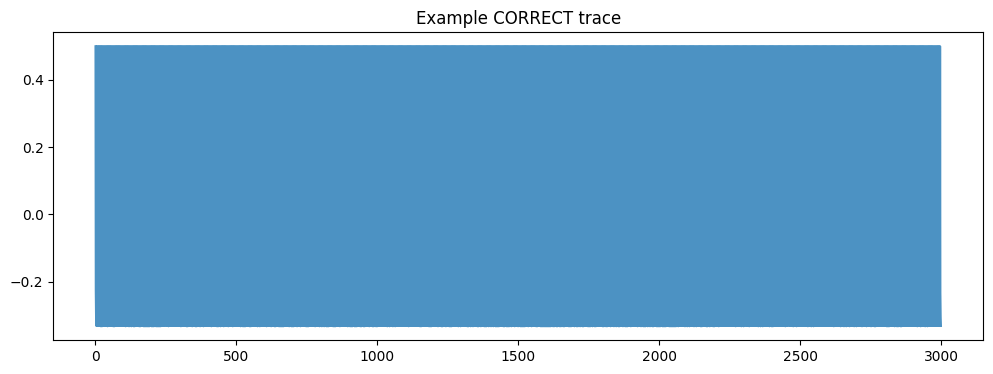

<Figure size 1200x400 with 0 Axes>

In [38]:
import matplotlib.pyplot as plt
import numpy as np

tr = traces_np
lab = np.array(labels)

fault_idx = np.where(lab == "faulty")[0]
corr_idx  = np.where(lab == "correct")[0]

plt.figure(figsize=(12,4))
if len(corr_idx) > 0:
    plt.plot(tr[corr_idx[0]], alpha=0.8)
    plt.title("Example CORRECT trace")
    plt.show()

plt.figure(figsize=(12,4))
if len(fault_idx) > 0:
    plt.plot(tr[fault_idx[0]], alpha=0.8)
    plt.title("Example FAULTY trace")
    plt.show()


In [24]:
print(scope.clock)

adc_src       = clkgen_x1
adc_phase     = 0
adc_freq      = 7384620
adc_rate      = 7384620.0
adc_locked    = True
freq_ctr      = 10000396
freq_ctr_src  = extclk
clkgen_src    = system
extclk_freq   = 10000000
clkgen_mul    = 2
clkgen_div    = 26
clkgen_freq   = 7384615.384615385
clkgen_locked = True



In [29]:
print([x for x in dir(scope.glitch) if "output" in x or "clk" in x or "repeat" in x])
print("glitch output =", scope.glitch.output)


['_output_modes', 'clk_src', 'output', 'repeat']
glitch output = clock_xor


In [28]:
import time
import numpy as np

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_once():
    scope.arm()
    launch_aes(PT)

    timed_out = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        return "no_trigger", ct
    elif ct == EXP_CT:
        return "correct", ct
    else:
        return "faulty", ct

# --- Glitch settings (stronger) ---
scope.io.glitch_lp = True
scope.io.glitch_hp = True
scope.glitch.clk_src = "clkgen"
scope.glitch.trigger_src = "ext_single"
scope.glitch.repeat = 10

# choose output mode
try:
    scope.glitch.output = "clock_or"
except Exception:
    scope.glitch.output = "clock_xor"

widths  = range(1, 49, 2)
offsets = range(-49, 49, 2)
tries_per_point = 10

hits = {"correct":0, "faulty":0, "no_trigger":0}
faults = []

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for _ in range(tries_per_point):
            label, ct = glitch_once()
            hits[label] += 1

            if label == "faulty":
                faults.append((w, off, ct.hex()))
                print("FAULT  w=", w, "off=", off, "ct=", ct.hex())
                break  # found a fault at this setting; move on

print("Summary:", hits)
print("Fault count:", len(faults))


Summary: {'correct': 11760, 'faulty': 0, 'no_trigger': 0}
Fault count: 0
